## **Optimizing Coffee Shop Placement in Makassar**: A Geospatial Data Science Approach using K-Means Clustering and Huff’s Gravity Model 
Oleh: Muh. Afrizal Nur

---

#### **Bussiness Problem (Latar Belakang)**

Pada akhir 2025, jumlah kedai kopi di Indonesia menembus angka 461.991 gerai. Angka ini membuat Indonesia menjadi salah satu negara dengan jumlah kedai kopi terbanyak di dunia. Kedai kopi di Indonesia tersebar ke berbagai provinsi, misalnya Sulawesi Selatan. Menurut data dari GoodStat, total ada 9.848 kedai kopi yang beroperasi di Sulawesi Selatan.  

In [9]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans


In [2]:
data_clean = pd.read_csv('dataset/data_clean.csv')

In [3]:
data_clean.head()

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
0,Kopi Teori New Chapter,4.7,452,Coffee shop,-5.155283,119.440105,"WARKOP SAMI, Jalan Boulevard, Masale, Panakkuk...",Masale,Panakkukang,Makassar
1,Kopikost - Coffee & Roastery,4.6,128,Coffee shop,-5.144494,119.452607,"Profesor Abdurrahman Basalamah, Karampuang, Pa...",Karampuang,Panakkukang,Makassar
2,Melos Coffee & Eatery,4.3,311,Coffee shop,-5.135454,119.434586,"Jalan Perkebunan, Sinrijala, Panakkukang, Maka...",Sinrijala,Panakkukang,Makassar
3,Institut KOPI,4.7,183,Coffee shop,-5.154309,119.439131,"Jalan Topaz Raya, Masale, Panakkukang, Makassa...",Masale,Panakkukang,Makassar
4,Postropis Coffee & Space,4.8,81,Coffee shop,-5.132992,119.433270,"Jalan Adipura Raya, Tamajeʼneʼ, Karuwisi Utara...",Karuwisi Utara,Panakkukang,Makassar


In [4]:
df = data_clean.copy()

## **Analisis Deskriptif**
---

In [18]:
df.describe()

,rating,jumlah_reviewer,lat,long,popularity_score,cluster
count,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000
mean,4.463969,106.445038,-5.144628,119.443451,14.641476,0.894656
std,1.040912,252.004550,0.023291,0.035453,8.119245,0.888541
min,0.000000,0.000000,-5.214848,119.327802,0.000000,0.000000
25%,4.500000,5.000000,-5.161365,119.417357,8.047190,0.000000
50%,4.700000,21.000000,-5.148688,119.431002,14.670394,1.000000
75%,5.000000,89.000000,-5.126659,119.458473,20.537002,2.000000
max,5.000000,3530.000000,-5.048941,119.531709,40.029748,2.000000


## **Visualisasi Sebaran**
---

Tujuan: *Hotspots*: Di mana titik-titik merah (kumpulan kedai kopi terbanyak)?

In [17]:
df['popularity_score'] = df['rating'] * np.log1p(df['jumlah_reviewer'])

# 3. K-MEANS CLUSTERING
# Menentukan zona berdasarkan lokasi (Lat, Long)
X = df[['lat', 'long']]
kmeans = KMeans(n_clusters=3, random_state=42) # Sesuaikan jumlah cluster (k)
df['cluster'] = kmeans.fit_predict(X)

# 4. VISUALISASI PETA INTERAKTIF (Folium)
# Titik tengah Makassar
makassar_coord = [-5.147, 119.432]
f = folium.Figure(width=1000, height=500)

m = folium.Map(location=makassar_coord, zoom_start=13, tiles='OpenStreetMap').add_to(f)

# A. Tambahkan Heatmap (Visualisasi Saturasi/Kejenuhan)
heat_data = [[row['lat'], row['long']] for index, row in df.iterrows()]
HeatMap(heat_data, name="Heatmap Saturasi").add_to(m)

# B. Tambahkan Marker untuk setiap Toko
for i, row in df.iterrows():
    # Warna marker berdasarkan cluster
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    color = colors[row['cluster'] % len(colors)]
    
    popup_text = f"""
    <b>{row['nama']}</b><br>
    Rating: {row['rating']}<br>
    Kecamatan: {row['kecamatan']}<br>
    Review: {row['jumlah_reviewer']}<br>
    Score: {row['popularity_score']:.2f}
    """
    
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=7,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=200)
    ).add_to(m)
m.save('analisis_geomarketing_makassar.html')
print("Analisis selesai! Buka file 'analisis_geomarketing_makassar.html' di browser Anda.")
m

Analisis selesai! Buka file 'analisis_geomarketing_makassar.html' di browser Anda.


In [8]:
df.sort_values(by="popularity_score", ascending=False)

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota,popularity_score,cluster
752,Lucé Gelato,4.9,3530,Cafe,-5.127119,119.408756,"Toko Cahaya oleh-oleh Makassar, Jalan Lembeh, ...",Ende,Wajo,Makassar,40.029748,2
673,Babathe X Luce Nusantara resto and gelato,5.0,2065,Cafe,-5.126891,119.408432,"Indomaret, Jalan Lembeh, Ende, Wajo, Makassar,...",Ende,Wajo,Makassar,38.166848,2
904,Warkop Azzahrah - Bandang,4.5,1920,Coffee shop,-5.122904,119.418671,"Warkop Az-zarah, Jalan Bandang I, Parang Layan...",Parang Layang,Bontoala,Makassar,34.022705,2
818,Warkop Five One,4.4,2254,Coffee shop,-5.119632,119.509392,"warkop 51, Jalan Puri Yuhana, Puri Yuhana Perm...",Daya,Biringkanaya,Makassar,33.971983,1
63,kopiteori,4.6,1597,Coffee shop,-5.157261,119.419732,"Jalan Beruang, Bonto Biraeng, Mamajang, Makass...",Bonto Biraeng,Mamajang,Makassar,33.931937,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1283,Kopi lounge,0.0,0,Coffee shop,-5.160624,119.407959,"Jalan Seruni, Kampung Buyang, Mariso, Makassar...",Kampung Buyang,Mariso,Makassar,0.000000,0
682,Kopi Abang,0.0,0,Coffee shop,-5.111969,119.421228,"Jalan Sabutung, Gusung, Ujung Tanah, Makassar,...",Gusung,Ujung Tanah,Makassar,0.000000,2
1264,Kopi Seduhu,0.0,0,Coffee store,-5.162441,119.406800,"Jalan Dahlia, Mattoangin, Mariso, Makassar, Su...",Mattoangin,Mariso,Makassar,0.000000,0
484,Kopi cinnaku,0.0,0,Coffee shop,-5.169717,119.447619,"Jalan Tamalate 3, Perumnas Tamalate, Kassiʼ-Ka...",Kassi-Kassi,Rappocini,Makassar,0.000000,0


In [15]:
df['kecamatan'].value_counts()

kecamatan
Rappocini                145
Biringkanaya             118
Tamalanrea               114
Panakkukang              111
Mamajang                 108
Mariso                   106
Manggala                 104
Tallo                    103
Ujung Pandang             96
Tamalate                  85
Wajo                      60
Ujung Tanah               60
Bontoala                  58
Makassar                  40
Kepulauan Sangkarrang      2
Name: count, dtype: int64

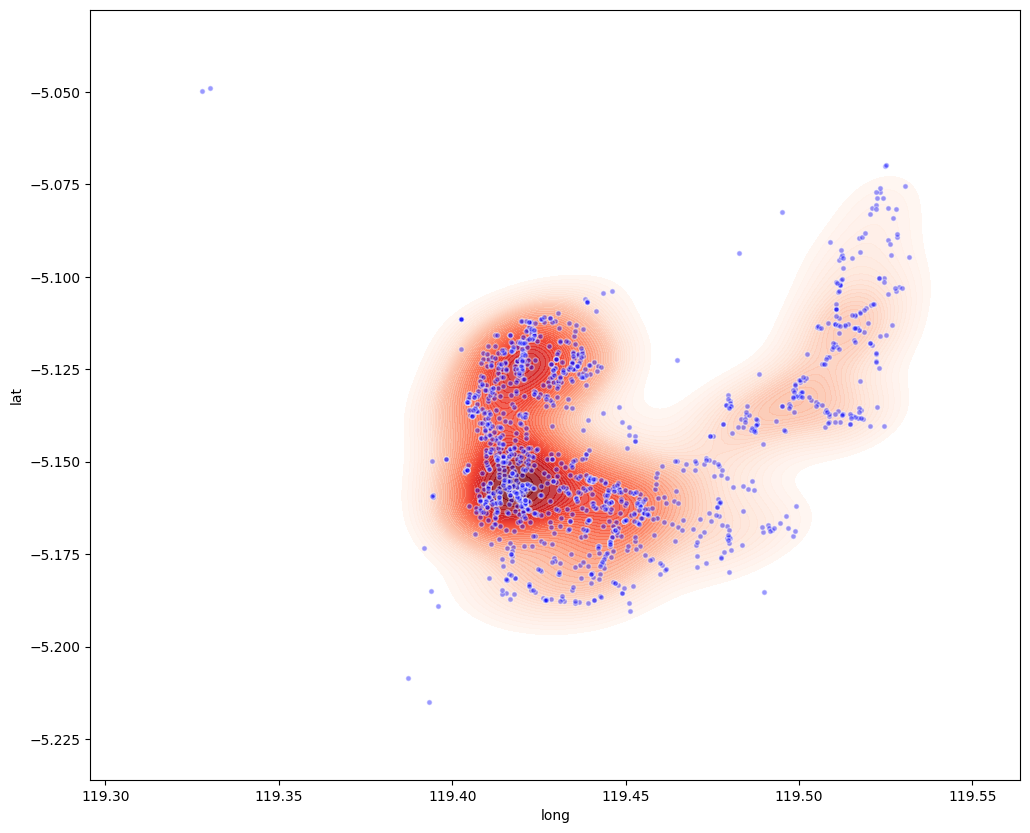

In [13]:
plt.figure(figsize=(12, 10))

sns.kdeplot(x=df['long'],
                 y=df['lat'],
                 fill=True,
                 thresh=0.05,
                 levels=50,
                 cmap="Reds",
                 alpha=0.8)

plt.scatter(df['long'],
            df['lat'],
            s=15,
            color='blue',
            alpha=0.4,
            edgecolors='white',
            label='Titik Coffee Shop')

plt.show()